# MSFT Verisi - Kronolojik Train, Validation ve Test Ayrımı

Bu notebook'un ilk amacı, MSFT kapanış fiyatı serisini zaman sırasını bozmadan üç döneme ayırmaktır. Bu aşamada ölçekleme, kayan pencere veya PyTorch tensorları oluşturulmaz.

**Ayrım oranları:**

- Train: ilk `%70`
- Validation: sonraki `%15`
- Test: son `%15`

Rastgele ayrım kullanılmaz; geçmiş verilerle daha yeni dönemleri tahmin etme koşulu korunur.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Kapanış fiyatı serisini yükleme

İlk model yalnızca düzeltilmiş `Close` fiyatını kullanacaktır. Diğer OHLCV alanları ham veride korunur, ancak bu notebook'taki ayrım hesabına dahil edilmez.

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Proje kökü bulunamadı. Notebook'u proje içinde çalıştırın.")

DATA_PATH = PROJECT_ROOT / "data/raw/msft_daily_latest.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError("Ham veri bulunamadı. Önce `uv run download-msft-data` çalıştırın.")

print(f"Veri dosyası: {DATA_PATH}")

Veri dosyası: C:\Users\brkbs\Desktop\Stock_Price_Prediction\data\raw\msft_daily_latest.csv


In [3]:
data = pd.read_csv(DATA_PATH, parse_dates=["Date"], index_col="Date").sort_index()
close_prices = data[["Close"]].copy()

assert close_prices.index.is_monotonic_increasing
assert not close_prices.index.has_duplicates
assert not close_prices.isna().any().any()

print(f"Toplam gözlem: {len(close_prices):,}")
print(f"Tarih aralığı: {close_prices.index.min().date()} - {close_prices.index.max().date()}")
display(close_prices.head())

Toplam gözlem: 4,156
Tarih aralığı: 2010-01-04 - 2026-07-14


,Close
Date,
2010-01-04,23.0275
2010-01-05,23.0349
2010-01-06,22.8936
2010-01-07,22.6555
2010-01-08,22.8117


## 2. Kronolojik ayrım

Sınırlar gözlem sayısına göre hesaplanır. İlk `%70` train, sonraki `%15` validation ve kalan gözlemler test dönemine atanır. Kesirli sonuçlar aşağı yuvarlandığı için kalan bir gözlem varsa test setinde tutulur.

In [4]:
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15

train_end = int(len(close_prices) * TRAIN_RATIO)
validation_end = train_end + int(len(close_prices) * VALIDATION_RATIO)

train_data = close_prices.iloc[:train_end].copy()
validation_data = close_prices.iloc[train_end:validation_end].copy()
test_data = close_prices.iloc[validation_end:].copy()

print(f"Train sınır indeksi: {train_end:,}")
print(f"Validation sınır indeksi: {validation_end:,}")

Train sınır indeksi: 2,909
Validation sınır indeksi: 3,532


In [5]:
split_summary = pd.DataFrame(
    {
        "Gözlem": [len(train_data), len(validation_data), len(test_data)],
        "Oran (%)": [
            len(train_data) / len(close_prices) * 100,
            len(validation_data) / len(close_prices) * 100,
            len(test_data) / len(close_prices) * 100,
        ],
        "Başlangıç": [
            train_data.index.min().date(),
            validation_data.index.min().date(),
            test_data.index.min().date(),
        ],
        "Bitiş": [
            train_data.index.max().date(),
            validation_data.index.max().date(),
            test_data.index.max().date(),
        ],
    },
    index=["Train", "Validation", "Test"],
)

split_summary

,Gözlem,Oran (%),Başlangıç,Bitiş
Train,2909,69.9952,2010-01-04,2021-07-23
Validation,623,14.9904,2021-07-26,2024-01-16
Test,624,15.0144,2024-01-17,2026-07-14


## 3. Ayrımın doğrulanması

Aşağıdaki kontroller üç bölümün boş olmadığını, doğru sırada bulunduğunu, kesişmediğini ve yeniden birleştirildiğinde orijinal seriyi eksiksiz oluşturduğunu doğrular.

In [6]:
assert len(train_data) > 0
assert len(validation_data) > 0
assert len(test_data) > 0

assert train_data.index.max() < validation_data.index.min()
assert validation_data.index.max() < test_data.index.min()

recombined = pd.concat([train_data, validation_data, test_data])
pd.testing.assert_frame_equal(recombined, close_prices)

assert train_data.index.intersection(validation_data.index).empty
assert train_data.index.intersection(test_data.index).empty
assert validation_data.index.intersection(test_data.index).empty

print("Ayrım kontrolleri başarılı: sıra doğru, çakışma ve kayıp gözlem yok.")

Ayrım kontrolleri başarılı: sıra doğru, çakışma ve kayıp gözlem yok.


## 4. Dönemlerin görselleştirilmesi

Her bölüm farklı renkle çizilir. Model train döneminden öğrenecek, validation dönemi model seçiminde kullanılacak ve test dönemi yalnızca nihai değerlendirmede açılacaktır.

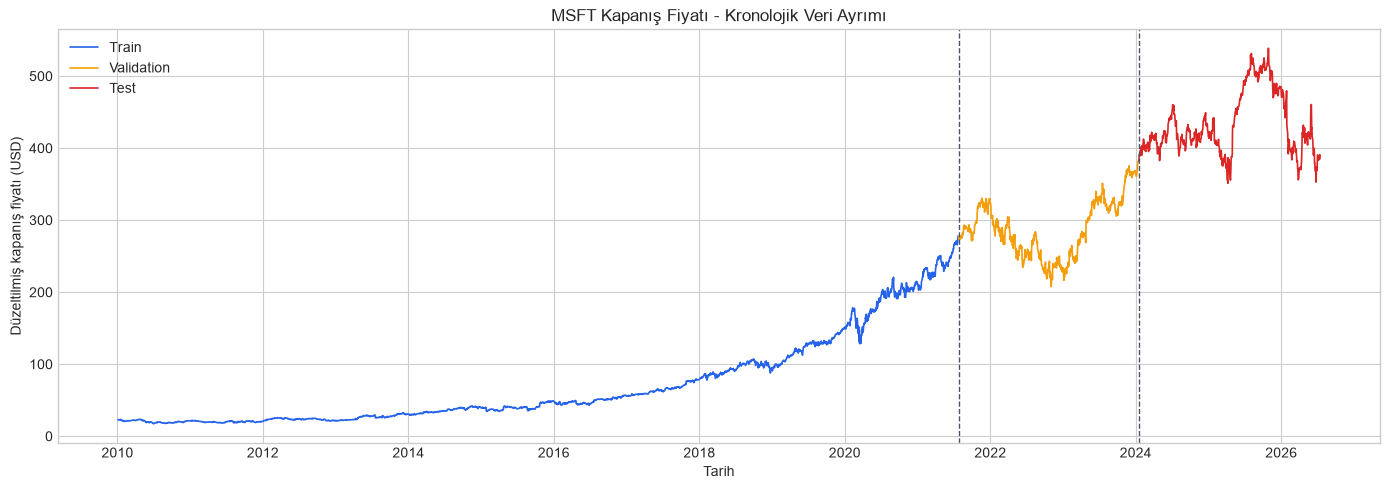

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_data.index, train_data["Close"], label="Train", color="#2563EB", linewidth=1.2)
ax.plot(
    validation_data.index,
    validation_data["Close"],
    label="Validation",
    color="#F59E0B",
    linewidth=1.2,
)
ax.plot(test_data.index, test_data["Close"], label="Test", color="#DC2626", linewidth=1.2)

ax.axvline(validation_data.index.min(), color="#475569", linestyle="--", linewidth=1)
ax.axvline(test_data.index.min(), color="#475569", linestyle="--", linewidth=1)
ax.set(
    title="MSFT Kapanış Fiyatı - Kronolojik Veri Ayrımı",
    xlabel="Tarih",
    ylabel="Düzeltilmiş kapanış fiyatı (USD)",
)
ax.legend()
fig.tight_layout()
plt.show()

## 5. Train verisine göre MinMax ölçekleme

LSTM ve GRU eğitiminde büyük fiyat değerleri yerine kontrollü bir sayısal aralık kullanmak optimizasyonu kolaylaştırır. PDF'deki başlangıç yaklaşımına uygun olarak fiyatlar `[-1, 1]` aralığına ölçeklenir.

Scaler yalnızca train döneminin minimum ve maksimum fiyatlarını öğrenir. Validation ve test dönemleri `fit` edilmez; aynı train dönüşümüyle yalnızca `transform` edilir. Böylece gelecekteki fiyat seviyeleri eğitim sürecine sızmaz.

In [8]:
scaler = MinMaxScaler(feature_range=(-1, 1))

train_scaled = pd.DataFrame(
    scaler.fit_transform(train_data),
    index=train_data.index,
    columns=["Close_Scaled"],
)
validation_scaled = pd.DataFrame(
    scaler.transform(validation_data),
    index=validation_data.index,
    columns=["Close_Scaled"],
)
test_scaled = pd.DataFrame(
    scaler.transform(test_data),
    index=test_data.index,
    columns=["Close_Scaled"],
)

scaler_summary = pd.Series(
    {
        "Fit edilen gözlem sayısı": scaler.n_samples_seen_,
        "Train minimum fiyatı": scaler.data_min_[0],
        "Train maksimum fiyatı": scaler.data_max_[0],
        "Öğrenilen fiyat aralığı": scaler.data_range_[0],
        "Hedef ölçek alt sınırı": scaler.feature_range[0],
        "Hedef ölçek üst sınırı": scaler.feature_range[1],
    },
    name="Değer",
)
scaler_summary.to_frame()

,Değer
Fit edilen gözlem sayısı,"2,909.0000"
Train minimum fiyatı,17.2776
Train maksimum fiyatı,277.9953
Öğrenilen fiyat aralığı,260.7176
Hedef ölçek alt sınırı,-1.0000
Hedef ölçek üst sınırı,1.0000


In [9]:
scaled_range_summary = pd.DataFrame(
    {
        "Orijinal minimum": [
            train_data["Close"].min(),
            validation_data["Close"].min(),
            test_data["Close"].min(),
        ],
        "Orijinal maksimum": [
            train_data["Close"].max(),
            validation_data["Close"].max(),
            test_data["Close"].max(),
        ],
        "Ölçeklenmiş minimum": [
            train_scaled["Close_Scaled"].min(),
            validation_scaled["Close_Scaled"].min(),
            test_scaled["Close_Scaled"].min(),
        ],
        "Ölçeklenmiş maksimum": [
            train_scaled["Close_Scaled"].max(),
            validation_scaled["Close_Scaled"].max(),
            test_scaled["Close_Scaled"].max(),
        ],
    },
    index=["Train", "Validation", "Test"],
)

scaled_range_summary

,Orijinal minimum,Orijinal maksimum,Ölçeklenmiş minimum,Ölçeklenmiş maksimum
Train,17.2776,277.9953,-1.0000,1.0000
Validation,207.7340,382.8317,0.4610,1.8042
Test,351.1058,538.6586,1.5608,2.9996


Validation veya test değerlerinin `[-1, 1]` dışına çıkması hata değildir. Bu durum, gelecekteki bir fiyatın train dönemindeki maksimumdan yüksek veya minimumdan düşük olduğunu gösterir. Bu değerleri zorla kırpmak bilgi kaybına yol açacağı için `clip=True` kullanılmaz.

In [10]:
assert scaler.n_samples_seen_ == len(train_data)
np.testing.assert_allclose(scaler.data_min_, train_data.min().to_numpy())
np.testing.assert_allclose(scaler.data_max_, train_data.max().to_numpy())

for original, scaled in [
    (train_data, train_scaled),
    (validation_data, validation_scaled),
    (test_data, test_scaled),
]:
    assert original.index.equals(scaled.index)
    reconstructed = scaler.inverse_transform(scaled)
    np.testing.assert_allclose(reconstructed, original.to_numpy(), rtol=1e-10, atol=1e-10)

print("Ölçekleme kontrolleri başarılı: scaler yalnızca train verisine fit edildi.")
print("Ters dönüşüm, üç veri bölümünde de orijinal fiyatları geri üretti.")

Ölçekleme kontrolleri başarılı: scaler yalnızca train verisine fit edildi.
Ters dönüşüm, üç veri bölümünde de orijinal fiyatları geri üretti.


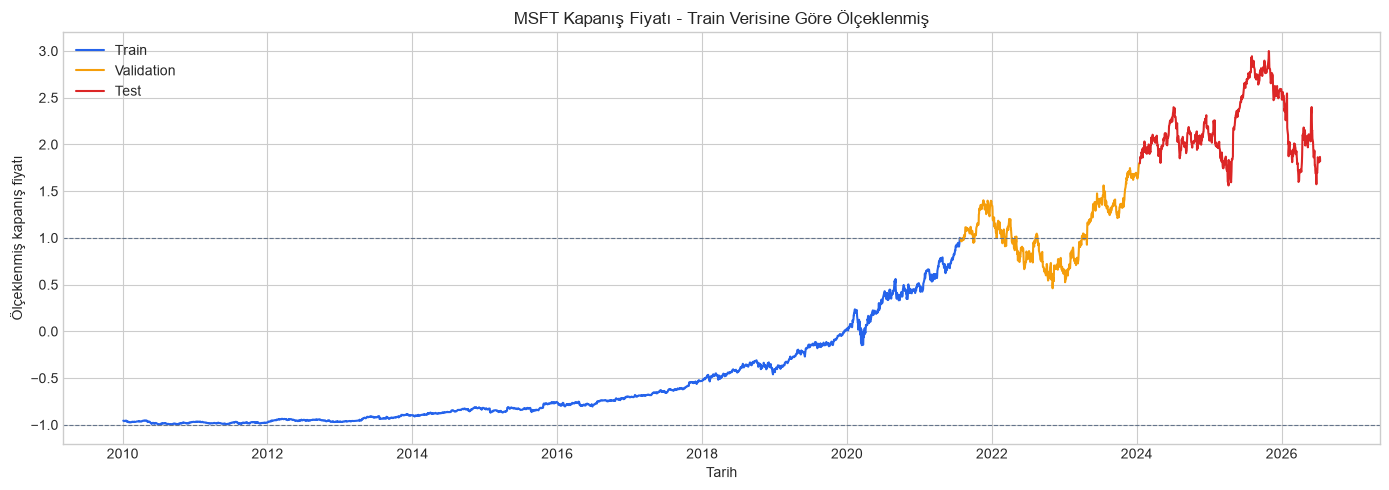

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_scaled.index, train_scaled["Close_Scaled"], label="Train", color="#2563EB")
ax.plot(
    validation_scaled.index,
    validation_scaled["Close_Scaled"],
    label="Validation",
    color="#F59E0B",
)
ax.plot(test_scaled.index, test_scaled["Close_Scaled"], label="Test", color="#DC2626")
ax.axhline(-1, color="#64748B", linestyle="--", linewidth=0.8)
ax.axhline(1, color="#64748B", linestyle="--", linewidth=0.8)
ax.set(
    title="MSFT Kapanış Fiyatı - Train Verisine Göre Ölçeklenmiş",
    xlabel="Tarih",
    ylabel="Ölçeklenmiş kapanış fiyatı",
)
ax.legend()
fig.tight_layout()
plt.show()

## 6. Değerlendirme

- Train, validation ve test dönemleri birbirini kronolojik olarak takip eder.
- Gelecekteki validation ve test fiyatları model eğitimine karışmaz.
- MinMaxScaler yalnızca train dönemindeki fiyat sınırlarını öğrenir.
- Validation ve test verileri aynı dönüşümle ölçeklenir; gelecekteki fiyatlar scaler fit işlemine katılmaz.
- Validation veya test değerlerinin `[-1, 1]` dışına çıkması beklenen ve bilgi taşıyan bir durumdur.
- Ters dönüşüm kontrolleri ölçeklenmiş değerlerden orijinal fiyatların geri alınabildiğini doğrular.
- Kayan pencereler daha sonra oluşturulurken örneklerin hangi sete ait olduğu hedef tarihe göre belirlenecektir.